<a href="https://colab.research.google.com/github/14marcos1/pesquisa_quimica_2026/blob/main/limiarizacao002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage import filters, measure, morphology
from skimage.segmentation import active_contour

Dimensões: (626, 700)


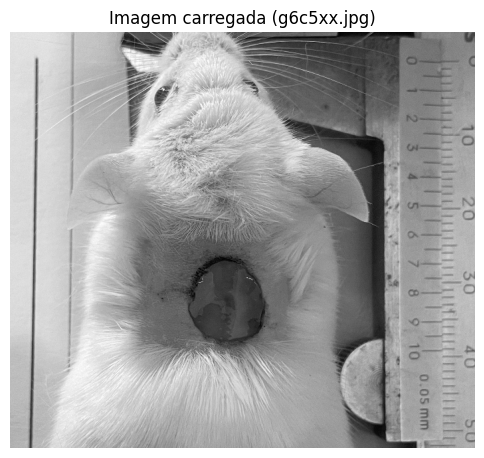

In [9]:
# BLOCO 1 — imports e leitura da imagem (g6c5xx.jpg)

!pip install -q opencv-python scikit-image scipy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt

# carregar imagem
img = cv2.imread('g6c5xx.jpg', cv2.IMREAD_GRAYSCALE)

# validação
if img is None:
    raise ValueError('Imagem g6c5xx.jpg não encontrada. Faça upload no Colab.')

# reduzir tamanho (evita travamento)
h, w = img.shape
escala = 700 / max(h, w)
if escala < 1:
    img = cv2.resize(img, (int(w * escala), int(h * escala)))

print('Dimensões:', img.shape)

# visualizar
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='gray')
plt.title('Imagem carregada (g6c5xx.jpg)')
plt.axis('off')
plt.show()

Dimensões ROI: (588, 492)


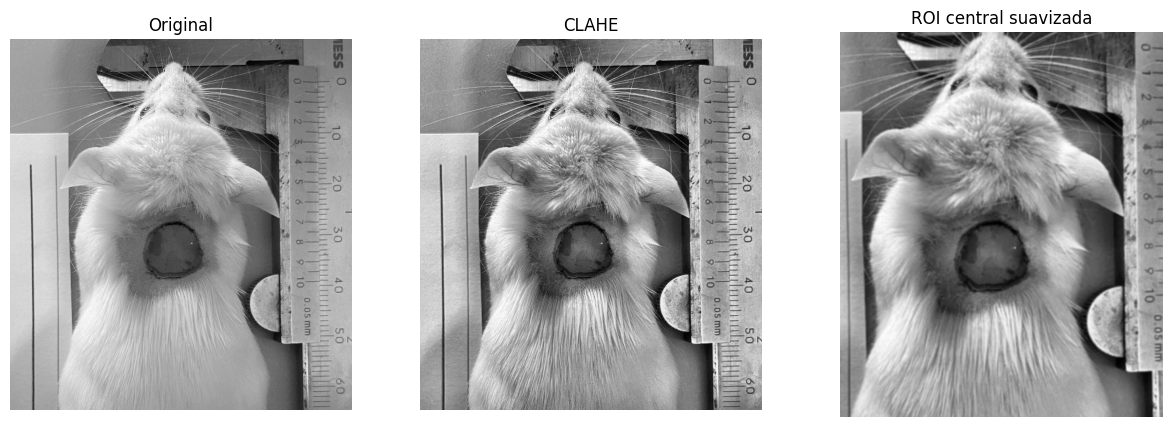

In [24]:
# BLOCO 2 — pré-processamento

from skimage import exposure

# melhorar contraste local
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_eq = clahe.apply(img)

# suavizar ruído preservando um pouco as bordas
img_blur = cv2.GaussianBlur(img_eq, (5,5), 0)

# recorte central para reduzir interferência das margens e da régua
h, w = img_blur.shape
margem_x = int(w * 0.12)
margem_y = int(h * 0.08)

img_roi = img_blur[margem_y:h-margem_y, margem_x:w-margem_x]

print('Dimensões ROI:', img_roi.shape)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_eq, cmap='gray')
plt.title('CLAHE')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_roi, cmap='gray')
plt.title('ROI central suavizada')
plt.axis('off')

plt.show()

Centróide estimado na ROI: (342.4, 202.9)


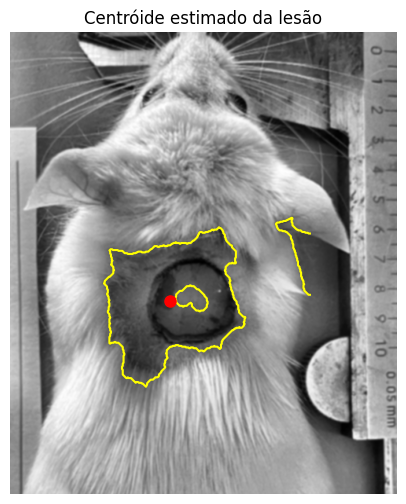

In [26]:
# BLOCO 3 — estimar centróide da lesão

from skimage import filters, measure, morphology

# definir uma região de busca mais central dentro da ROI
h, w = img_roi.shape

yc1, yc2 = int(h * 0.30), int(h * 0.78)
xc1, xc2 = int(w * 0.20), int(w * 0.78)

busca = img_roi[yc1:yc2, xc1:xc2]

# threshold de Otsu
th = filters.threshold_otsu(busca)

# lesão tende a ser mais escura
mask = busca < (th * 0.75)

# limpeza morfológica
mask = morphology.remove_small_objects(mask, min_size=1500)
mask = morphology.remove_small_holes(mask, area_threshold=1000)
mask = morphology.binary_closing(mask, morphology.disk(9))

# rotular componentes conectados
labels = measure.label(mask)
regs = measure.regionprops(labels)

if len(regs) == 0:
    raise ValueError("Nenhuma região detectada. Ajuste o fator do threshold ou o min_size.")

# escolher o maior componente
maior = max(regs, key=lambda r: r.area)

# centróide dentro da região de busca
cy, cx = maior.centroid

# converter para coordenadas da img_roi
cy_full = cy + yc1
cx_full = cx + xc1

print(f'Centróide estimado na ROI: ({cy_full:.1f}, {cx_full:.1f})')

# visualizar
plt.figure(figsize=(6,6))
plt.imshow(img_roi, cmap='gray')
plt.contour(
    mask,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)
plt.plot(cx_full, cy_full, 'ro', markersize=8)
plt.title('Centróide estimado da lesão')
plt.axis('off')
plt.show()

Centróide estimado na ROI: (342.0, 205.3)
Área da região escolhida: 21413.0


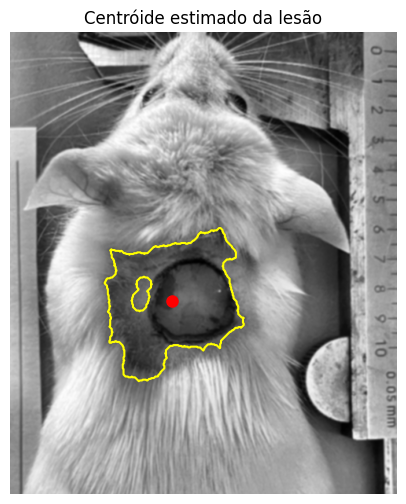

In [27]:
# BLOCO 3 — estimar centróide da lesão (versão melhorada)

from skimage import filters, measure, morphology
import numpy as np
import matplotlib.pyplot as plt

# definir uma região de busca mais central dentro da ROI
h, w = img_roi.shape

yc1, yc2 = int(h * 0.30), int(h * 0.78)
xc1, xc2 = int(w * 0.20), int(w * 0.78)

busca = img_roi[yc1:yc2, xc1:xc2]

# threshold de Otsu
th = filters.threshold_otsu(busca)

# lesão tende a ser mais escura
mask = busca < (th * 0.72)

# limpeza morfológica
mask = morphology.remove_small_objects(mask, min_size=1500)
mask = morphology.remove_small_holes(mask, area_threshold=1500)
mask = morphology.binary_closing(mask, morphology.disk(9))

# rotular componentes conectados
labels = measure.label(mask)
regs = measure.regionprops(labels)

if len(regs) == 0:
    raise ValueError("Nenhuma região detectada. Ajuste o fator do threshold ou os parâmetros morfológicos.")

# centro de referência = centro da janela de busca
centro_ref = np.array([mask.shape[0] / 2, mask.shape[1] / 2])

# escolher a região mais próxima do centro, favorecendo também áreas maiores
candidatos = []
for r in regs:
    dist = np.linalg.norm(np.array(r.centroid) - centro_ref)
    candidatos.append((dist, -r.area, r))

candidatos.sort(key=lambda x: (x[0], x[1]))
melhor = candidatos[0][2]

# centróide dentro da região de busca
cy, cx = melhor.centroid

# converter para coordenadas da img_roi
cy_full = cy + yc1
cx_full = cx + xc1

print(f'Centróide estimado na ROI: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Área da região escolhida: {melhor.area}')

# visualizar
plt.figure(figsize=(6, 6))
plt.imshow(img_roi, cmap='gray')

plt.contour(
    mask,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

plt.plot(cx_full, cy_full, 'ro', markersize=8)
plt.title('Centróide estimado da lesão')
plt.axis('off')
plt.show()

Centróide estimado na ROI: (348.1, 212.3)
Área da região escolhida: 16230.0
Compacidade da região escolhida: 0.384


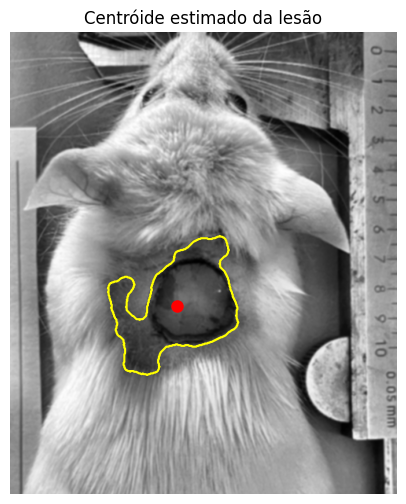

In [28]:
# BLOCO 3 — estimar centróide da lesão (versão refinada)

from skimage import filters, measure, morphology
import numpy as np
import matplotlib.pyplot as plt

# definir uma região de busca mais central dentro da ROI
h, w = img_roi.shape

yc1, yc2 = int(h * 0.30), int(h * 0.78)
xc1, xc2 = int(w * 0.20), int(w * 0.78)

busca = img_roi[yc1:yc2, xc1:xc2]

# threshold de Otsu
th = filters.threshold_otsu(busca)

# lesão tende a ser mais escura
mask = busca < (th * 0.68)

# limpeza morfológica mais agressiva
mask = morphology.remove_small_objects(mask, min_size=1800)
mask = morphology.remove_small_holes(mask, area_threshold=1800)
mask = morphology.binary_opening(mask, morphology.disk(8))
mask = morphology.binary_closing(mask, morphology.disk(9))

# rotular componentes conectados
labels = measure.label(mask)
regs = measure.regionprops(labels)

if len(regs) == 0:
    raise ValueError("Nenhuma região detectada. Ajuste o fator do threshold ou os parâmetros morfológicos.")

# centro de referência = centro da janela de busca
centro_ref = np.array([mask.shape[0] / 2, mask.shape[1] / 2])

# escolher a região com melhor equilíbrio entre centralidade e compacidade
candidatos = []

for r in regs:
    per = r.perimeter if r.perimeter > 0 else 1
    comp = 4 * np.pi * r.area / (per ** 2)   # compacidade: quanto mais perto de 1, mais compacto
    dist = np.linalg.norm(np.array(r.centroid) - centro_ref)

    # score menor = melhor
    score = dist - 200 * comp

    candidatos.append((score, r))

candidatos.sort(key=lambda x: x[0])
melhor = candidatos[0][1]

# centróide dentro da região de busca
cy, cx = melhor.centroid

# converter para coordenadas da img_roi
cy_full = cy + yc1
cx_full = cx + xc1

print(f'Centróide estimado na ROI: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Área da região escolhida: {melhor.area}')
print(f'Compacidade da região escolhida: {4 * np.pi * melhor.area / (melhor.perimeter ** 2 + 1e-8):.3f}')

# visualizar
plt.figure(figsize=(6, 6))
plt.imshow(img_roi, cmap='gray')

plt.contour(
    mask,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

plt.plot(cx_full, cy_full, 'ro', markersize=8)
plt.title('Centróide estimado da lesão')
plt.axis('off')
plt.show()

Centro da elipse: (348.1, 212.3)
Semi-eixos estimados: rx=95.4, ry=101.8


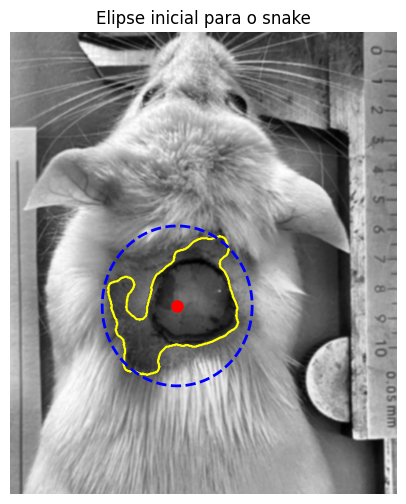

In [23]:
# BLOCO 4 — gerar elipse inicial automática para o snake

import numpy as np
import matplotlib.pyplot as plt

# usar a região escolhida no bloco anterior
minr, minc, maxr, maxc = melhor.bbox

# centro da elipse = centróide da região escolhida
cy, cx = melhor.centroid

# semi-eixos com pequena expansão
ry = (maxr - minr) / 2 * 1.15
rx = (maxc - minc) / 2 * 1.15

# gerar pontos da elipse
t = np.linspace(0, 2 * np.pi, 120)
y_init = cy + ry * np.sin(t)
x_init = cx + rx * np.cos(t)

# converter para coordenadas da img_roi
y_init_full = y_init + yc1
x_init_full = x_init + xc1

print(f'Centro da elipse: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Semi-eixos estimados: rx={rx:.1f}, ry={ry:.1f}')

# visualizar
plt.figure(figsize=(6, 6))
plt.imshow(img_roi, cmap='gray')

# contorno amarelo da máscara escolhida
plt.contour(
    labels == melhor.label,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

# centróide
plt.plot(cx_full, cy_full, 'ro', markersize=8)

# elipse inicial
plt.plot(x_init_full, y_init_full, '--b', linewidth=2)

plt.title('Elipse inicial para o snake')
plt.axis('off')
plt.show()

Centro da elipse: (348.1, 212.3)
Semi-eixos estimados: rx=83.0, ry=88.5


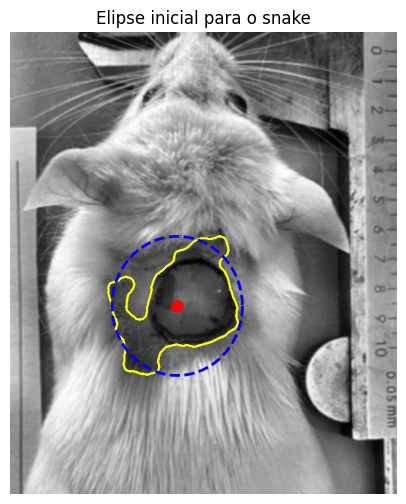

In [29]:
# BLOCO 4 — gerar elipse inicial automática para o snake (mais justa)

import numpy as np
import matplotlib.pyplot as plt

# usar a região escolhida no bloco anterior
minr, minc, maxr, maxc = melhor.bbox

# centro da elipse = centróide da região escolhida
cy, cx = melhor.centroid

# semi-eixos sem expansão extra
ry = (maxr - minr) / 2 * 1.00
rx = (maxc - minc) / 2 * 1.00

# gerar pontos da elipse
t = np.linspace(0, 2 * np.pi, 120)
y_init = cy + ry * np.sin(t)
x_init = cx + rx * np.cos(t)

# converter para coordenadas da img_roi
y_init_full = y_init + yc1
x_init_full = x_init + xc1

print(f'Centro da elipse: ({cy_full:.1f}, {cx_full:.1f})')
print(f'Semi-eixos estimados: rx={rx:.1f}, ry={ry:.1f}')

# visualizar
plt.figure(figsize=(6, 6))
plt.imshow(img_roi, cmap='gray')

# contorno da região escolhida
plt.contour(
    labels == melhor.label,
    levels=[0.5],
    colors='yellow',
    origin='image',
    extent=[xc1, xc2, yc2, yc1]
)

# centróide
plt.plot(cx_full, cy_full, 'ro', markersize=8)

# elipse inicial
plt.plot(x_init_full, y_init_full, '--b', linewidth=2)

plt.title('Elipse inicial para o snake')
plt.axis('off')
plt.show()